# Loss calculation

Switching loss from the SPICE models, no board.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

`coaxial.inverter` carries the stage's constants: FSW, the dead time, the FET's junction law (CJO, M, VJ from the LTSpice model), the power loop inductance, the shunt and the sense chain. None is a measurement on this board unless its comment says which.

In [2]:
from coaxial import inverter

print('FSW %.0f Hz  TS %.1f us  T_DEAD %.1f ns  T_DEAD_SIM %.1f ns  T_MIN_PULSE %.0f ns'
      % (inverter.FSW, inverter.TS * 1e6, inverter.T_DEAD * 1e9,
         inverter.T_DEAD_SIM * 1e9, inverter.T_MIN_PULSE * 1e9))
print('RDS_ON %.1f mohm  SHUNT %.1f mohm  L_LOOP %.1f nH  Q_RING %.1f (assumed)'
      % (inverter.RDS_ON * 1e3, inverter.SHUNT * 1e3, inverter.L_LOOP * 1e9, inverter.Q_RING))
print('CJO %.1f nF  M %.2f  VJ %.2f' % (inverter.CJO * 1e9, inverter.M, inverter.VJ))
print('AFE %.3f V/A, delay %.0f ns, %.1f mA per count, noise %s A rms measured'
      % (inverter.AFE_V_PER_A, inverter.AFE_DELAY * 1e9, inverter.AFE_A_PER_COUNT * 1e3,
         inverter.NOISE_A))

FSW 50000 Hz  TS 20.0 us  T_DEAD 33.7 ns  T_DEAD_SIM 65.4 ns  T_MIN_PULSE 76 ns
RDS_ON 1.8 mohm  SHUNT 3.5 mohm  L_LOOP 4.0 nH  Q_RING 1.0 (assumed)
CJO 15.6 nF  M 0.45  VJ 0.70
AFE 0.016 V/A, delay 60 ns, 3.2 mA per count, noise (0.35, 0.41) A rms measured


Coss and Qoss over the link sweep, and the stored energy `E_oss = integral of v C(v) dv`: the capacitive part of a hard switched edge, dissipated once per turn-on per switch.

 vdc   Coss nF   Qoss nC   E_oss uJ   P_coss W/switch
   23      3.20     117.9      1.071      0.054
   33      2.73     147.4      1.891      0.095
   43      2.43     173.0      2.865      0.143
   53      2.21     196.2      3.974      0.199
   63      2.05     217.5      5.207      0.260


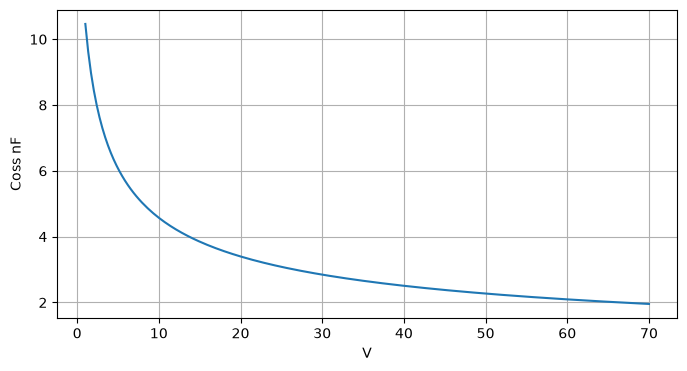

In [3]:
import numpy as np
import matplotlib.pyplot as plt

VDC = (23.0, 33.0, 43.0, 53.0, 63.0)

def e_oss(v, steps=2000):
    grid = np.linspace(0.0, v, steps)
    return np.trapezoid(grid * inverter.coss(grid), grid)

print(' vdc   Coss nF   Qoss nC   E_oss uJ   P_coss W/switch')
for vdc in VDC:
    e = e_oss(vdc)
    print('%5.0f   %7.2f   %7.1f   %8.3f   %8.3f'
          % (vdc, inverter.coss(vdc) * 1e9, inverter.qoss(vdc) * 1e9, e * 1e6, e * inverter.FSW))
volts = np.linspace(1.0, 70.0, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(volts, inverter.coss(volts) * 1e9)
ax.set_xlabel('V'); ax.set_ylabel('Coss nF'); ax.grid(True)
plt.show()

The switch-node ring, the blanking margin left for the current sample, and the dead-time voltage error with its knee: what the firmware's compensation table is built from.

In [4]:
print(' vdc   f_ring MHz   tau ns   settle ns   Z ohm   blanking ns   V_dt V   knee A')
for vdc in VDC:
    r = inverter.ring(vdc)
    print('%5.0f   %9.1f   %6.2f   %8.1f   %6.2f   %10.1f   %6.3f   %6.2f'
          % (vdc, r['f_hz'] / 1e6, r['tau_s'] * 1e9, r['settle_s'] * 1e9, r['z_ohm'],
             inverter.blanking(vdc) * 1e9, inverter.dead_time_volts(vdc), inverter.knee_amps(vdc)))
step, table = inverter.dt_table(43.0)
print('43 V table: step %.2f A, volts %s' % (step, [round(v, 3) for v in table]))

 vdc   f_ring MHz   tau ns   settle ns   Z ohm   blanking ns   V_dt V   knee A
   23        31.5    10.12       46.6     0.79        143.4    0.039     7.00
   33        34.1     9.34       43.0     0.86        147.0    0.056     8.74
   43        36.1     8.81       40.6     0.91        149.4    0.072    10.27
   53        37.8     8.41       38.8     0.95        151.2    0.089    11.64
   63        39.3     8.10       37.3     0.99        152.7    0.106    12.91
43 V table: step 5.13 A, volts [0.0, 0.033, 0.055, 0.066, 0.07, 0.071, 0.072, 0.072]


Conduction: `I^2 (RDS_ON + SHUNT)` per phase, RDS_ON at 25 C. The thermal network's measured switching figure is 1.20 W for three legs at 50 % on 24.6 V (`coaxial.thermal.POWER_SWITCHING`).

In [5]:
from coaxial import thermal

print('measured switching power, three legs 50 %% at 24.6 V: %.2f W'
      % sum(thermal.POWER_SWITCHING.values()))
print('  I A   conduction W/phase')
for amps in (1.0, 5.0, 20.0, 50.0, 100.0):
    print('%5.0f   %8.2f' % (amps, amps * amps * (inverter.RDS_ON + inverter.SHUNT)))

measured switching power, three legs 50 % at 24.6 V: 2.40 W
  I A   conduction W/phase
    1       0.01
    5       0.13
   20       2.12
   50      13.25
  100      53.00


## Conclusions

In [6]:
print('MEASURED on this board:')
print('   NOISE_A            %s A rms, the phase noise floor' % (inverter.NOISE_A,))
print('   T_DEAD             %.1f ns, DTG 8, trimmed against the supply OCP' % (inverter.T_DEAD * 1e9))
print('TRACED from the schematic:')
print('   SHUNT              %.1f mohm, two 7 mohm in parallel' % (inverter.SHUNT * 1e3))
print('   AFE_V_PER_A        %.3f V/A, 4.5455 V/V x the shunt' % inverter.AFE_V_PER_A)
print('FROM THE PART AND THE SIMULATION:')
print('   CJO / M / VJ       %.1f nF / %.2f / %.2f, the VDMOS junction law'
      % (inverter.CJO * 1e9, inverter.M, inverter.VJ))
print('   RDS_ON             %.1f mohm' % (inverter.RDS_ON * 1e3))
print('   AFE_DELAY          %.0f ns, from the AFE simulation' % (inverter.AFE_DELAY * 1e9))
print('ASSUMED:')
print('   Q_RING             %.1f, the ring damping' % inverter.Q_RING)
print('   L_LOOP             %.1f nH, 0.25 nH/mm over the layout' % (inverter.L_LOOP * 1e9))
print()
print('blanking margin at 63 V: %.1f ns' % (inverter.blanking(63.0) * 1e9))

MEASURED on this board:
   NOISE_A            (0.35, 0.41) A rms, the phase noise floor
   T_DEAD             33.7 ns, DTG 8, trimmed against the supply OCP
TRACED from the schematic:
   SHUNT              3.5 mohm, two 7 mohm in parallel
   AFE_V_PER_A        0.016 V/A, 4.5455 V/V x the shunt
FROM THE PART AND THE SIMULATION:
   CJO / M / VJ       15.6 nF / 0.45 / 0.70, the VDMOS junction law
   RDS_ON             1.8 mohm
   AFE_DELAY          60 ns, from the AFE simulation
ASSUMED:
   Q_RING             1.0, the ring damping
   L_LOOP             4.0 nH, 0.25 nH/mm over the layout

blanking margin at 63 V: 152.7 ns


`ring()` gives the switch node's frequency, its decay and its impedance from L_LOOP against both FETs' Coss. `blanking()` rests on the settling time and is what says whether the current sample lands on settled current: a quarter of the modulator's unused window, minus the ring and the sense chain's delay.

`knee_amps` is the current that just slews the switch node across the link inside the dead time, `2 Qoss / t_dead`: below it the output charge soft-switches the error away, which is the tanh knee the firmware's compensation table and the motor model share. `dt_table` samples that curve every half knee - eight points, held past the last - and those are record ids 34 to 42.

The thermal calibration's own figure sits beside these: 1.20 W for three legs at 50 % on 24.6 V, of which roughly half fell on the supply corner - gate charge comes out of the +15V7 buck - and half on the bridge.